# Steps
- And end-to-end Scikit-Learn workflow
- Getting data ready
- Choosing a machine learning model
- Fitting a model to the data (learning patterns)
- Making pedictions with a model
- Evaluating model predictions
- Improving model predictions
- Saving and loading models

- **heart_disease** - a classification dataset (predicting wheather someone has heart disease or not)
- **boston_df** - a regression dataset (predicting the median house prices of cities in Boston)

### 0 And end-to-end scikit learn workflow

In [1]:
# 1. Get the data ready
import pandas as pd
import numpy as np
heart_disease = pd.read_csv('heart-disease.csv')

In [2]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
# Create X (feature matrix)
X = heart_disease.drop(columns=['target'])

# Create Y (labels)
y = heart_disease['target']

In [4]:
# Choose the right model and hyperparameters
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100)

# We'll keep default hyperparameters
clf.get_params() # is a method not a attribute get_params_

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [5]:
# 3. Fit the model to the training data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [6]:
clf.fit(X_train, y_train);

In [7]:
# make a prediction
# y_label = clf.predict(np.array([0,2,3,4]))

In [8]:
X_test # tiene misma shape

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
145,70,1,1,156,245,0,0,143,0,0.0,2,0,2
185,44,1,0,112,290,0,0,153,0,0.0,2,1,2
168,63,1,0,130,254,0,0,147,0,1.4,1,1,3
209,59,1,0,140,177,0,1,162,1,0.0,2,1,3
192,54,1,0,120,188,0,1,113,0,1.4,1,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
144,76,0,2,140,197,0,2,116,0,1.1,1,0,2
195,59,1,0,170,326,0,0,140,1,3.4,0,0,3
62,52,1,3,118,186,0,0,190,0,0.0,1,0,1
85,67,0,2,115,564,0,0,160,0,1.6,1,0,3


In [9]:
y_preds = clf.predict(X_test)
y_preds

array([1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1])

In [10]:
y_test

145    1
185    0
168    0
209    0
192    0
      ..
144    1
195    0
62     1
85     1
135    1
Name: target, Length: 61, dtype: int64

In [11]:
# 4. Evaluate the model
# Return :ref:`accuracy <accuracy_score>` on provided data and labels.
# score : float. Mean accuracy of ``self.predict(X)``
clf.score(X_train, y_train)

1.0

In [12]:
clf.score(X_test, y_test)

0.8524590163934426

In [13]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.88      0.78      0.82        27
           1       0.84      0.91      0.87        34

    accuracy                           0.85        61
   macro avg       0.86      0.84      0.85        61
weighted avg       0.85      0.85      0.85        61



In [14]:
print(confusion_matrix(y_test, y_preds))

[[21  6]
 [ 3 31]]


In [15]:
print(accuracy_score(y_test, y_preds))

0.8524590163934426


In [16]:
# 5. Improve model
# Try differente amount of n_estimators
np.random.seed(42)
for i in range(10, 100, 10):
    print(f'Try model with {i} estimators...')
    clf = RandomForestClassifier(n_estimators=i).fit(X_train, y_train)
    print(f'Model accuracy on test set: {clf.score(X_test, y_test) * 100}')
    print('')

Try model with 10 estimators...
Model accuracy on test set: 83.60655737704919

Try model with 20 estimators...
Model accuracy on test set: 90.1639344262295

Try model with 30 estimators...
Model accuracy on test set: 83.60655737704919

Try model with 40 estimators...
Model accuracy on test set: 85.24590163934425

Try model with 50 estimators...
Model accuracy on test set: 81.9672131147541

Try model with 60 estimators...
Model accuracy on test set: 86.88524590163934

Try model with 70 estimators...
Model accuracy on test set: 88.52459016393442

Try model with 80 estimators...
Model accuracy on test set: 83.60655737704919

Try model with 90 estimators...
Model accuracy on test set: 86.88524590163934



In [17]:
# 6. Save a model and load it
import pickle

In [18]:
pickle.dump(clf, open('random_forest_model_1.pkl', 'wb'))

In [19]:
loaded_model = pickle.load(open('random_forest_model_1.pkl', 'rb'))
loaded_model.score(X_test, y_test)

0.8688524590163934

In [20]:
import sklearn
sklearn.show_versions()


System:
    python: 3.13.7 | packaged by Anaconda, Inc. | (main, Sep  9 2025, 19:54:37) [MSC v.1929 64 bit (AMD64)]
executable: c:\Users\andre\Documents\udemy_vscode\env\python.exe
   machine: Windows-11-10.0.26200-SP0

Python dependencies:
      sklearn: 1.7.2
          pip: 25.2
   setuptools: 72.1.0
        numpy: 2.3.3
        scipy: 1.16.1
       Cython: None
       pandas: 2.3.2
   matplotlib: 3.10.6
       joblib: 1.5.2
threadpoolctl: 3.5.0

Built with OpenMP: True

threadpoolctl info:
       user_api: blas
   internal_api: mkl
    num_threads: 4
         prefix: mkl_rt
       filepath: C:\Users\andre\Documents\udemy_vscode\env\Library\bin\mkl_rt.2.dll
        version: 2025.0-Product
threading_layer: intel

       user_api: openmp
   internal_api: openmp
    num_threads: 8
         prefix: vcomp
       filepath: C:\Users\andre\Documents\udemy_vscode\env\vcomp140.dll
        version: None


# 110. Getting your data ready: splitting your data

In [21]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

- 1. Split the data into features and labels (usuall 'X' & 'Y')
- 2. Filling (also called imputing) or disregarding missing values
- 3. Converting non-numerical values into numerical values (also called feature enncoding)

In [22]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [23]:
X = heart_disease.drop(columns=['target'])
y = heart_disease['target']

In [24]:
# Split your data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [25]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((242, 13), (61, 13), (242,), (61,))

In [26]:
# Another example
# Import car-sales-extended.csv
# car_sales = pd.read_csv("../data/car-sales-extended.csv") # load data from local directory 
car_sales = pd.read_csv("https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/car-sales-extended.csv") # load data directly from raw URL (source: https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/data/car-sales-extended.csv)
car_sales

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043
...,...,...,...,...,...
995,Toyota,Black,35820,4,32042
996,Nissan,White,155144,3,5716
997,Nissan,Blue,66604,4,31570
998,Honda,White,215883,4,4001


In [27]:
car_sales.dtypes

Make             object
Colour           object
Odometer (KM)     int64
Doors             int64
Price             int64
dtype: object

In [28]:
# Split into X & y and train/test
X = car_sales.drop("Price", axis=1)
y = car_sales["Price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [29]:
# Try to predict with random forest on price column (doesn't work)
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor() # it can predict a number
# model.fit(X_train, y_train)
# model.score(X_test, y_test)

In [30]:
car_sales.Doors.value_counts()

Doors
4    856
5     79
3     65
Name: count, dtype: int64

In [31]:
# 1. Import OneHotEncoder and ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# 2. Define the categorical features to transform
categorical_features = ["Make", "Colour", "Doors"]

# 3. Create an instance of OneHotEncoder
one_hot = OneHotEncoder()

# 4. Create an instance of ColumnTransformer
transformer = ColumnTransformer([("one_hot", # name
                                  one_hot, # transformer
                                  categorical_features)], # columns to transform
                                  remainder="passthrough") # what to do with the rest of the columns? ("passthrough" = leave unchanged) 

# 5. Turn the categorical features into numbers (this will return an array-like sparse matrix, not a DataFrame)
transformed_X = transformer.fit_transform(X)
transformed_X

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 3.54310e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 1.92714e+05],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 8.47140e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 6.66040e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.15883e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.48360e+05]], shape=(1000, 13))

In [32]:
car_sales.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043


In [33]:
pd.DataFrame(transformed_X)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,35431.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,192714.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,84714.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,154365.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,181577.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35820.0
996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,155144.0
997,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,66604.0
998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,215883.0


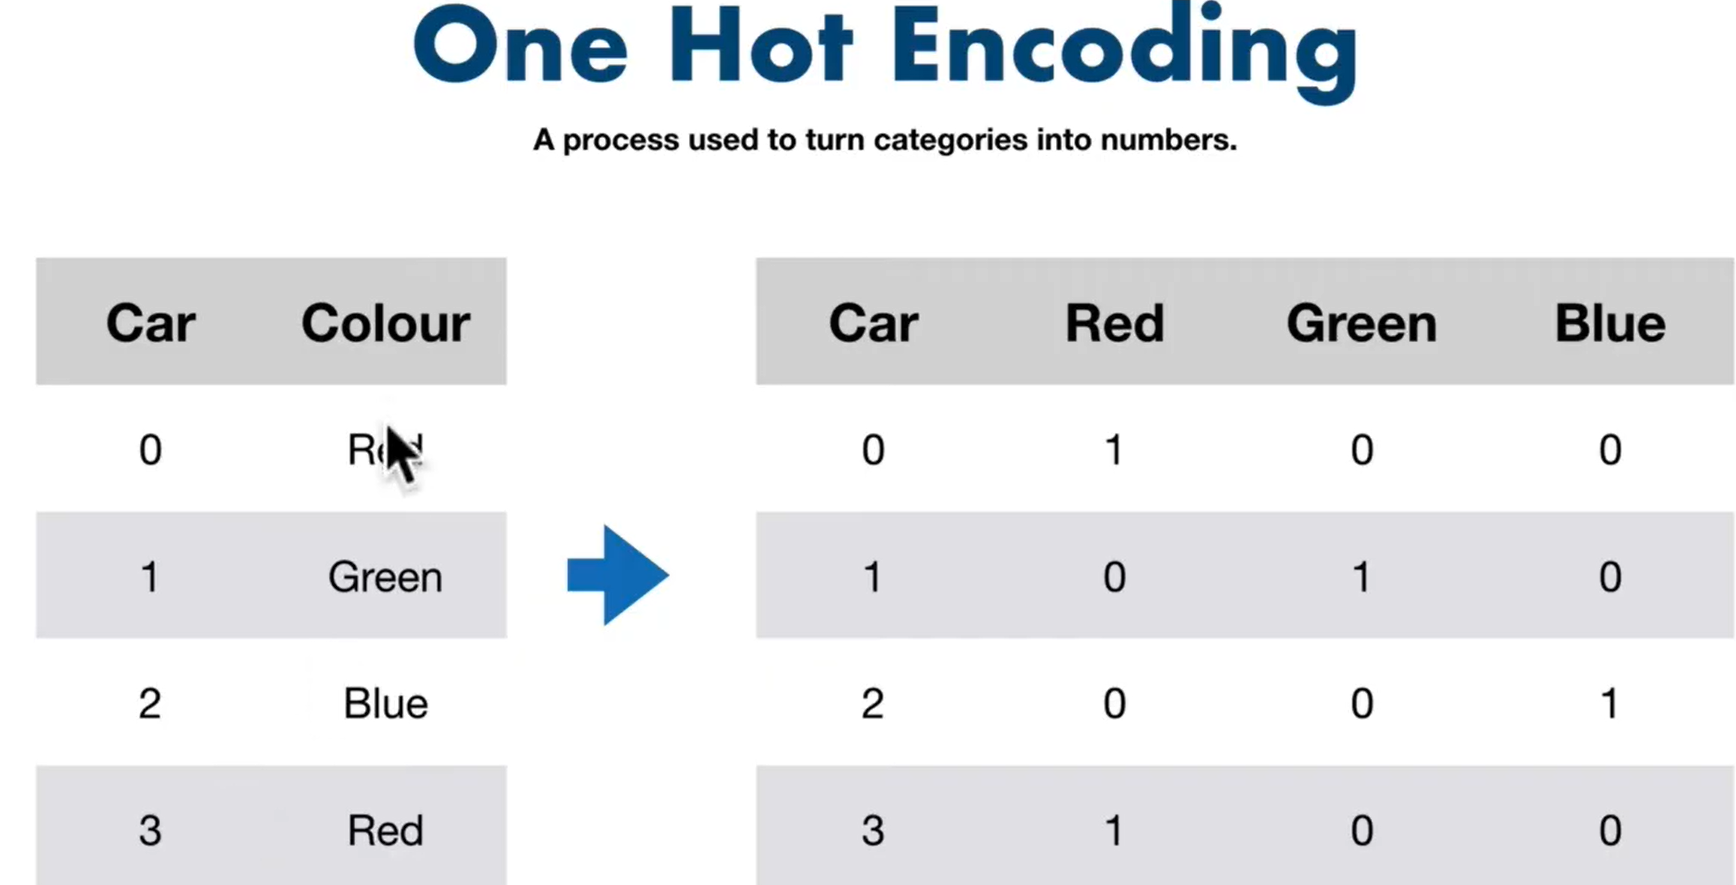

In [34]:
# Have to convert doors to object for dummies to work on it...
car_sales["Doors"] = car_sales["Doors"].astype(object)
dummies = pd.get_dummies(data=car_sales[["Make", "Colour", "Doors"]], dtype=float)
dummies

,Make_BMW,Make_Honda,Make_Nissan,Make_Toyota,Colour_Black,Colour_Blue,Colour_Green,Colour_Red,Colour_White,Doors_3,Doors_4,Doors_5
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
997,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


- If you're performing quick data analysis and running small modelling experiments, use pandas as it's generally quite fast to get up and running.
- If you're performing a larger scale modelling experiment or would like to put your data processing steps into a production pipeline, I'd recommend leaning towards Scikit-Learn, specifically a Scikit-Learn Pipeline (chaining together multiple estimator/modelling steps).

In [35]:
np.random.seed(42)

# Create train and test splits with transformed_X
X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=0.2)

# Create the model instance
model = RandomForestRegressor()

# Fit the model on the numerical data (this errored before since our data wasn't fully numeric)
model.fit(X_train, y_train)

# Score the model (returns r^2 metric by default, also called coefficient of determination, higher is better)
model.score(X_test, y_test)

0.3235867221569877

## 1.2 What if there were missing values in the data?

- Fill them with some given or calculated value (imputation)
- Remove them

In [36]:
# Import car sales dataframe with missing values
# car_sales_missing = pd.read_csv("../data/car-sales-extended-missing-data.csv") # load from local directory
car_sales_missing = pd.read_csv("https://raw.githubusercontent.com/mrdbourke/zero-to-mastery-ml/master/data/car-sales-extended-missing-data.csv") # read directly from URL (source: https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/data/car-sales-extended-missing-data.csv)

In [37]:
car_sales_missing.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

After drop o fill missing values we need to use **Feature Scaling**.
In other words, making sure all of your numerical data is on the same scale.

- Normalization (also called min-max scaling) - This rescales all the numerical values to between 0 and 1, with the lowest value being close to 0 and the highest previous value being close to 1. Scikit-Learn provides functionality for this in the MinMaxScalar class.

- Standardization - This subtracts the mean value from all of the features (so the resulting features have 0 mean). It then scales the features to unit variance (by dividing the feature by the standard deviation). Scikit-Learn provides functionality for this in the StandardScalar class.


Feature scaling usually isn't required for your target variable.

Feature scaling is usually not required with tree-based models (e.g. Random Forest) since they can handle varying features.

### Option 2: fill missing values with scikit-learn

In [38]:
car_sales_missing.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0


In [39]:
car_sales_missing.dropna(subset='Price', inplace=True)
car_sales_missing.isna().sum()

Make             47
Colour           46
Odometer (KM)    48
Doors            47
Price             0
dtype: int64

In [40]:
# Split into X & y and train/test
X = car_sales_missing.drop("Price", axis=1)
y = car_sales_missing["Price"]

In [41]:
X.isna().sum()

Make             47
Colour           46
Odometer (KM)    48
Doors            47
dtype: int64

In [42]:
# Fill missing values with scikit-learn
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Fill categorical values with 'missing' & numerical values with mean
# Create categorical variable imputer
cat_imputer = SimpleImputer(strategy="constant", fill_value="missing")

# Create Door column imputer
door_imputer = SimpleImputer(strategy="constant", fill_value=4)

# Create Odometer (KM) column imputer
num_imputer = SimpleImputer(strategy="mean")


# Define different column features
categorical_features = ["Make", "Colour"]  
door_feature = ["Doors"]
numerical_feature = ["Odometer (KM)"]

# Create series of column transforms to perform
imputer = ColumnTransformer([
    ("cat_imputador", cat_imputer, categorical_features),
    ("door_imputador", door_imputer, door_feature),
    ("num_imputador", num_imputer, numerical_feature)])

# Transform the data
filled_X = imputer.fit_transform(X)
filled_X

array([['Honda', 'White', 4.0, 35431.0],
       ['BMW', 'Blue', 5.0, 192714.0],
       ['Honda', 'White', 4.0, 84714.0],
       ...,
       ['Nissan', 'Blue', 4.0, 66604.0],
       ['Honda', 'White', 4.0, 215883.0],
       ['Toyota', 'Blue', 4.0, 248360.0]], shape=(950, 4), dtype=object)

In [43]:
# name_of_transform = "cat_imputador"
# transformer_to_use = cat_imputer (the instance of SimpleImputer() we defined above)
# columns_to_transform = categorical_features (the list of categorical features we defined above).

In [44]:
car_sales_missing.columns

Index(['Make', 'Colour', 'Odometer (KM)', 'Doors', 'Price'], dtype='object')

In [45]:
car_sales_filled = pd.DataFrame(filled_X, columns=['Make', 'Colour', 'Doors', 'Odometer (KM)'])

In [46]:
car_sales_filled.isna().sum()

Make             0
Colour           0
Doors            0
Odometer (KM)    0
dtype: int64

In [47]:
# 1. Import OneHotEncoder and ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# 2. Define the categorical features to transform
categorical_features = ["Make", "Colour", "Doors"]

# 3. Create an instance of OneHotEncoder
one_hot = OneHotEncoder()

# 4. Create an instance of ColumnTransformer
transformer = ColumnTransformer([("one_hot", # name
                                  one_hot, # transformer
                                  categorical_features)], # columns to transform
                                  remainder="passthrough") # what to do with the rest of the columns? ("passthrough" = leave unchanged) 

# 5. Turn the categorical features into numbers (this will return an array-like sparse matrix, not a DataFrame)
transformed_X = transformer.fit_transform(car_sales_filled)
transformed_X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3800 stored elements and shape (950, 15)>

In [48]:
# Now we've got our data as numbers and filled
# Let's fit a model
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

np.random.seed(42)
# Create train and test splits with transformed_X
X_train, X_test, y_train, y_test = train_test_split(
    transformed_X, y, test_size=0.2
)

# Create the model instance
model = RandomForestRegressor()
# Fit the model on the numerical data (this errored before since our data wasn't fully numeric)
model.fit(X_train, y_train)
# Score the model (returns r^2 metric by default, also called coefficient of determination, higher is better)
model.score(X_test, y_test)

0.21990196728583944

In [49]:
# we got a worst result 0.21 vs 0.32
len(car_sales_filled), len(car_sales)

(950, 1000)

### Choosing the right estimator/algorithm
Notes:
- Sklearn refers to machine learning models, algorithms as estimators
- Classification problem - predicting a category (heart disease or not)
    - Sometimes you'll see ´clf´ short for classifier used as classification estimator
- Regression problema - predicting a number (selling price of a car)

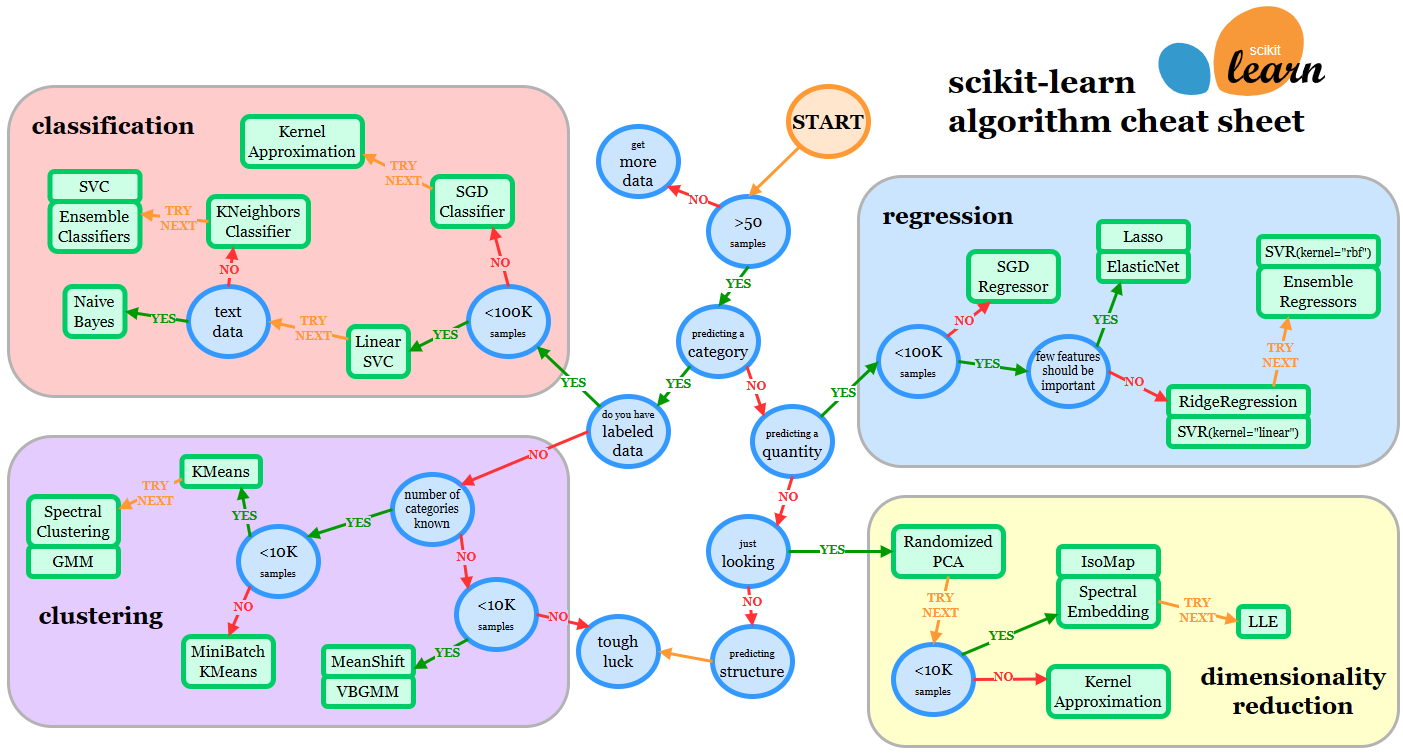

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html#sklearn.datasets.fetch_california_housing

In [50]:
# Get California Housing dataset for our regression model
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [51]:
housing_df = pd.DataFrame(housing['data'], columns=housing['feature_names'])
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [52]:
housing_df['MedHouseVal'] = housing['target']

In [53]:
housing_df['target'] = housing['target']
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,3.422


In [54]:
housing_df.drop(columns='MedHouseVal', inplace=True)

In [55]:
# Import algorithm
from sklearn.linear_model import Ridge

# Setup a random seed
np.random.seed(42)

# Create the data
X = housing_df.drop('target', axis=1)
y = housing_df['target'] # median house price in $100,000s

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate and fit the model (on the training set)
model = Ridge()
model.fit(X_train, y_train)

# Check the score of the model (on the test set)
model.score(X_test, y_test) # this returns the coefficient of determination on test data

# sirve para predecir o probar hipótesis
# El coeficiente determina la calidad del modelo para replicar los resultados, y la proporción de variación de los resultados

0.5758549611440126

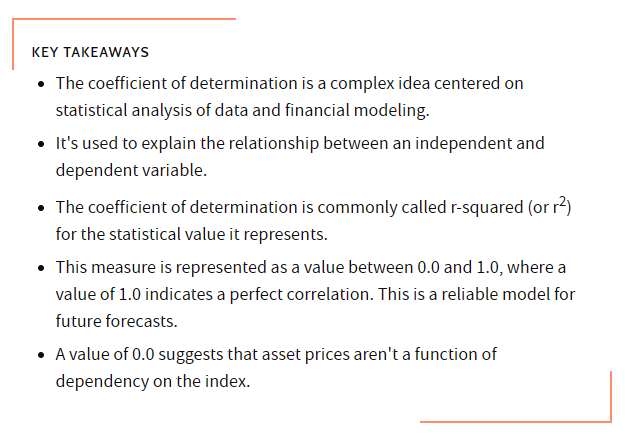

Now we're going to dive more into different regression evaluation metrics, but what you should know is that the default regression evaluation metric is for regression models in psychic learn is this R squared value.

And so what this is saying here is that it measures the linear relationship between two variables.

In our case, we've got a few more than two variables, but essentially it's taking the relationship between these variables.

## Another option is try another method

1.11. Ensembles: Gradient boosting, random forests, bagging, voting, stacking

Ensemble methods combine the predictions of several base estimators built with a given learning algorithm in order to improve generalizability / robustness over a single estimator

Two very famous examples of ensemble methods are gradient-boosted trees and random forests.

In [56]:
# Ensemble model is a combination of smaller models to try and make better predictions
# than just a single model
# william koehrsen

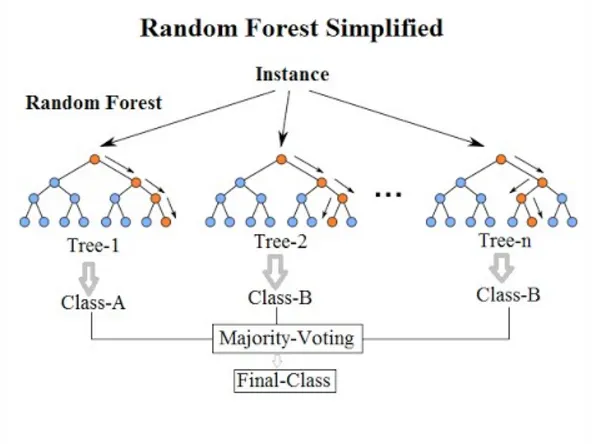

### RANDOM FOREST REGRESSOR
*Is a scikit-learn meta-estimator that fits multiple decision tree regressors on various sub-samples of a dataset and uses averaging to improve predictive accuracy while controlling overfitting*

In [57]:
from sklearn.ensemble import RandomForestRegressor

# Setup a random seed
np.random.seed(42)

# Create the data
X = housing_df.drop('target', axis=1)
y = housing_df['target']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate and fit the model
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

# Check the score of the model
model.score(X_test, y_test) # this returns the coefficient of determination on test data

0.806652667101436

### Picking a ml model for classification problem

In [58]:
heart_disease = pd.read_csv('heart-disease.csv')
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [59]:
heart_disease.shape

(303, 14)

### 1.4.1. Classification of Support Vector Classification (SVC)

SVC, NuSVC and LinearSVC are classes capable of performing binary and multi-class classification on a dataset.

| Feature | SVC | NuSVC | LinearSVC |
|---------|-----|-------|-----------|
| Backend | libsvm | libsvm | liblinear |
| Kernels | Linear, RBF, Poly, Sigmoid | Linear, RBF, Poly, Sigmoid | Linear only |
| Regularizer |  C | v(nu) |  C
 Multiclass | One-vs-One (OvO) | One-vs-One (OvO) | One-vs-Rest (OvR) |
| Efficiency | Lower (Quadratic/Cubic) | Lower (Quadratic/Cubic) | High (Scales linearly) |

## LINEAR SVC

- Avoids the overhead of kernel matrices
- Loss Function: Defaults to squared hinge loss
- One-vs-Rest is faster for problems with many classes

In [60]:
# Import the linear svc estimator class
from sklearn.svm import LinearSVC


# setup random seed
np.random.seed(42)

# Make the data
X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate LinearSVC
clf = LinearSVC(max_iter=10000)
clf.fit(X_train, y_train)

# Evaluate
clf.score(X_test, y_test)

0.8688524590163934

### **Difference between RandomForestClassifier and RandomForestRegressor**
Is the type of target variable they predict and how they aggregate the results from individual decision trees

| Feature | RandomForestClassifier | RandomForestRegressor |
|---------|------------------------|----------------------|
| Output Type | Categorical (Discrete classes, e.g., Spam vs. Not Spam) | Continuous (Numerical values, e.g., Price, Temperature) |
| Aggregation | Majority Vote: The class predicted by the most trees is chosen. | Averaging: The final prediction is the mean of all individual tree outputs. |
| Default Scoring | Mean Accuracy: Percentage of correct classifications. | Coefficient of Determination (r**2): Explains variance in the data. |
| Criterion | Measures quality of split using Gini impurity or Entropy. | Measures quality of split using Mean Squared Error (MSE) or MAE.



Implementation Specifics
- **Target Variables:** Use the RandomForestClassifier documentation when your 
 variable contains labels (strings or integers representing categories). Use the RandomForestRegressor documentation when 
 is a range of floating-point numbers.
- **Probability Estimation:** RandomForestClassifier includes a .predict_proba() method to estimate the likelihood of each class. While a regressor can technically be used on 0/1 data, it will not output true probabilities and may even predict values outside the 0–1 range.
- **Hyperparameters:** Most hyperparameters are identical, but max_features defaults differently in scikit-learn: it typically defaults to the square root of total features for classification and the total number of features (or 1 in some older versions/implementations) for regression. 

### RANDOM FOREST CLASSIFIER
*Is a supervised machine learning algorithm that combines multiple decision trees to improve predictive accuracy. It is highly effective for tabular data and handles large datasets and nonlinear relationships well.*

**`-RandomForestClassifier` ----->	Majority Vote: The class predicted by the most trees is chosen**

**`-RandomForestRegressor` -----> The final prediction is the mean of all individual tree outputs**

In [61]:
# Import the RandomForestCLassifier estimator class
from sklearn.ensemble import RandomForestClassifier


# setup random seed
np.random.seed(42)

# Make the data
X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train, y_train)

# Evaluate
clf.score(X_test, y_test)

0.8524590163934426

### *If you have structured data, used ensemble methods*
### *If you have unstructured data, use deep learning or transfer learning*

# 3. Fit the model on our data and use it to make predictions

In [62]:
# Import the RandomForestCLassifier estimator class
from sklearn.ensemble import RandomForestClassifier


# setup random seed
np.random.seed(42)

# Make the data
X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100)

# Fit the model to the data (training the machine learning model)
clf.fit(X_train, y_train)

# Evaluate (use the patterns the model has learned)
clf.score(X_test, y_test)

0.8524590163934426

In [63]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [64]:
y.tail()

298    0
299    0
300    0
301    0
302    0
Name: target, dtype: int64

## 3.2 Make predictions

Two ways to make predictions:
1. `predict()` function
2. `predict_proba()` function

In [65]:
 # Use a trained model
clf.predict(X_test) # out model use training data to learn so it's perfect

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [66]:
np.array([y_test])

array([[0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
        0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0]])

In [67]:
# Compare predictions to truth labels to evaluate the model
y_preds = clf.predict(X_test) # save in a variable
np.mean(y_preds == y_test) # calculate the accurracy

np.float64(0.8524590163934426)

In [68]:
clf.score(X_test, y_test)

0.8524590163934426

In [69]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_preds)

0.8524590163934426

## 3.2.1 Make predictions with predict_proba()
#### Returns probabilities of a classification label

- The **predict_proba method returns the class probabilities for each input** data point rather than just a single label. 
- The **predict()** method gives you **a direct classification** (e.g., "Spam" or "Not Spam")

predict_proba() provides the underlying confidence levels for every possible class, [0, 1]

In [70]:
clf.predict_proba(X_test[:5])

array([[0.89, 0.11],
       [0.49, 0.51],
       [0.43, 0.57],
       [0.84, 0.16],
       [0.18, 0.82]])

In [71]:
clf.predict(X_test[:5])

array([0, 1, 1, 0, 1])

In [72]:
# s it's making predictions on the same data, but instead of just returning the label,
# it's returning the probability of that label being true
# this means the first row has a 89% of probability of being cero and
# the last have just 18%, so is going to be 1

`predict()` can also be used for regression models

In [73]:
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## RandomForestRegressor

In [74]:
from sklearn.ensemble import RandomForestRegressor

# setup random seed
np.random.seed(42)

# Make the data
X = housing_df.drop("target", axis=1)
y = housing_df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate RandomForestRegressor
model = RandomForestRegressor(n_estimators=100)

# Fit the model to the data (training the machine learning model)
model.fit(X_train, y_train)

# Evaluate (use the patterns the model has learned)
y_preds = model.predict(X_test)

In [75]:
y_preds[: 10]

array([0.4939   , 0.75494  , 4.9285964, 2.54024  , 2.33176  , 1.6602201,
       2.3431   , 1.66311  , 2.47489  , 4.8344779])

In [76]:
np.array(y_test[:10])

array([0.477  , 0.458  , 5.00001, 2.186  , 2.78   , 1.587  , 1.982  ,
       1.575  , 3.4    , 4.466  ])

In [77]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, y_preds)

0.32656738464147306

## 4. Evaluating a machine learning model

Three ways to evaluate scikit-learn models/estimators:
1. Estimator's built-in `score()` method
2. The `scoring` parameter
3. Problem-specific metric functions

### 4.1 Evaluating a model with `score` method

In [78]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Create the data
X = heart_disease.drop('target', axis=1)
y = heart_disease['target']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate the RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100)

# Fit classifier to training data
clf.fit(X_train, y_train);

In [79]:
# The highest value for the .score() method is 1.0, the lowest is 0.0
print(clf.score(X_train, y_train))

# training score must be higher than test score
print(clf.score(X_test, y_test))

1.0
0.8524590163934426


#### Let's use `score()` on our regression problem

In [80]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Create the data
X = housing_df.drop('target', axis=1)
y = housing_df['target']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate the RandomForestRegressor
model = RandomForestRegressor(n_estimators=10)

# Fit classifier to training data
model.fit(X_train, y_train);

In [81]:
# The default score() evaluation metric is r_squared for regression algorithms
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.9626597968483063
0.7869919586520553


### 4.2 Evaluating a model using the `scoring` parameter

In [82]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

# Create the data
X = heart_disease.drop('target', axis=1)
y = heart_disease['target']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate the RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100)

# Fit classifier to training data
clf.fit(X_train, y_train);

In [83]:
clf.score(X_test, y_test)

0.8524590163934426

In [84]:
cross_val_score(clf, X, y, cv=5)

array([0.81967213, 0.86885246, 0.81967213, 0.78333333, 0.76666667])

In [85]:
cross_val_score(clf, X, y, cv=10)

array([0.90322581, 0.80645161, 0.87096774, 0.9       , 0.86666667,
       0.8       , 0.73333333, 0.86666667, 0.73333333, 0.8       ])

Cross-validation (CV) is a powerful model evaluation technique that assesses how well a model generalizes to new data by splitting the dataset into training and testing subsets, training on one part, and validating on the other, 
repeating this process to get a reliable performance estimate and prevent overfitting,

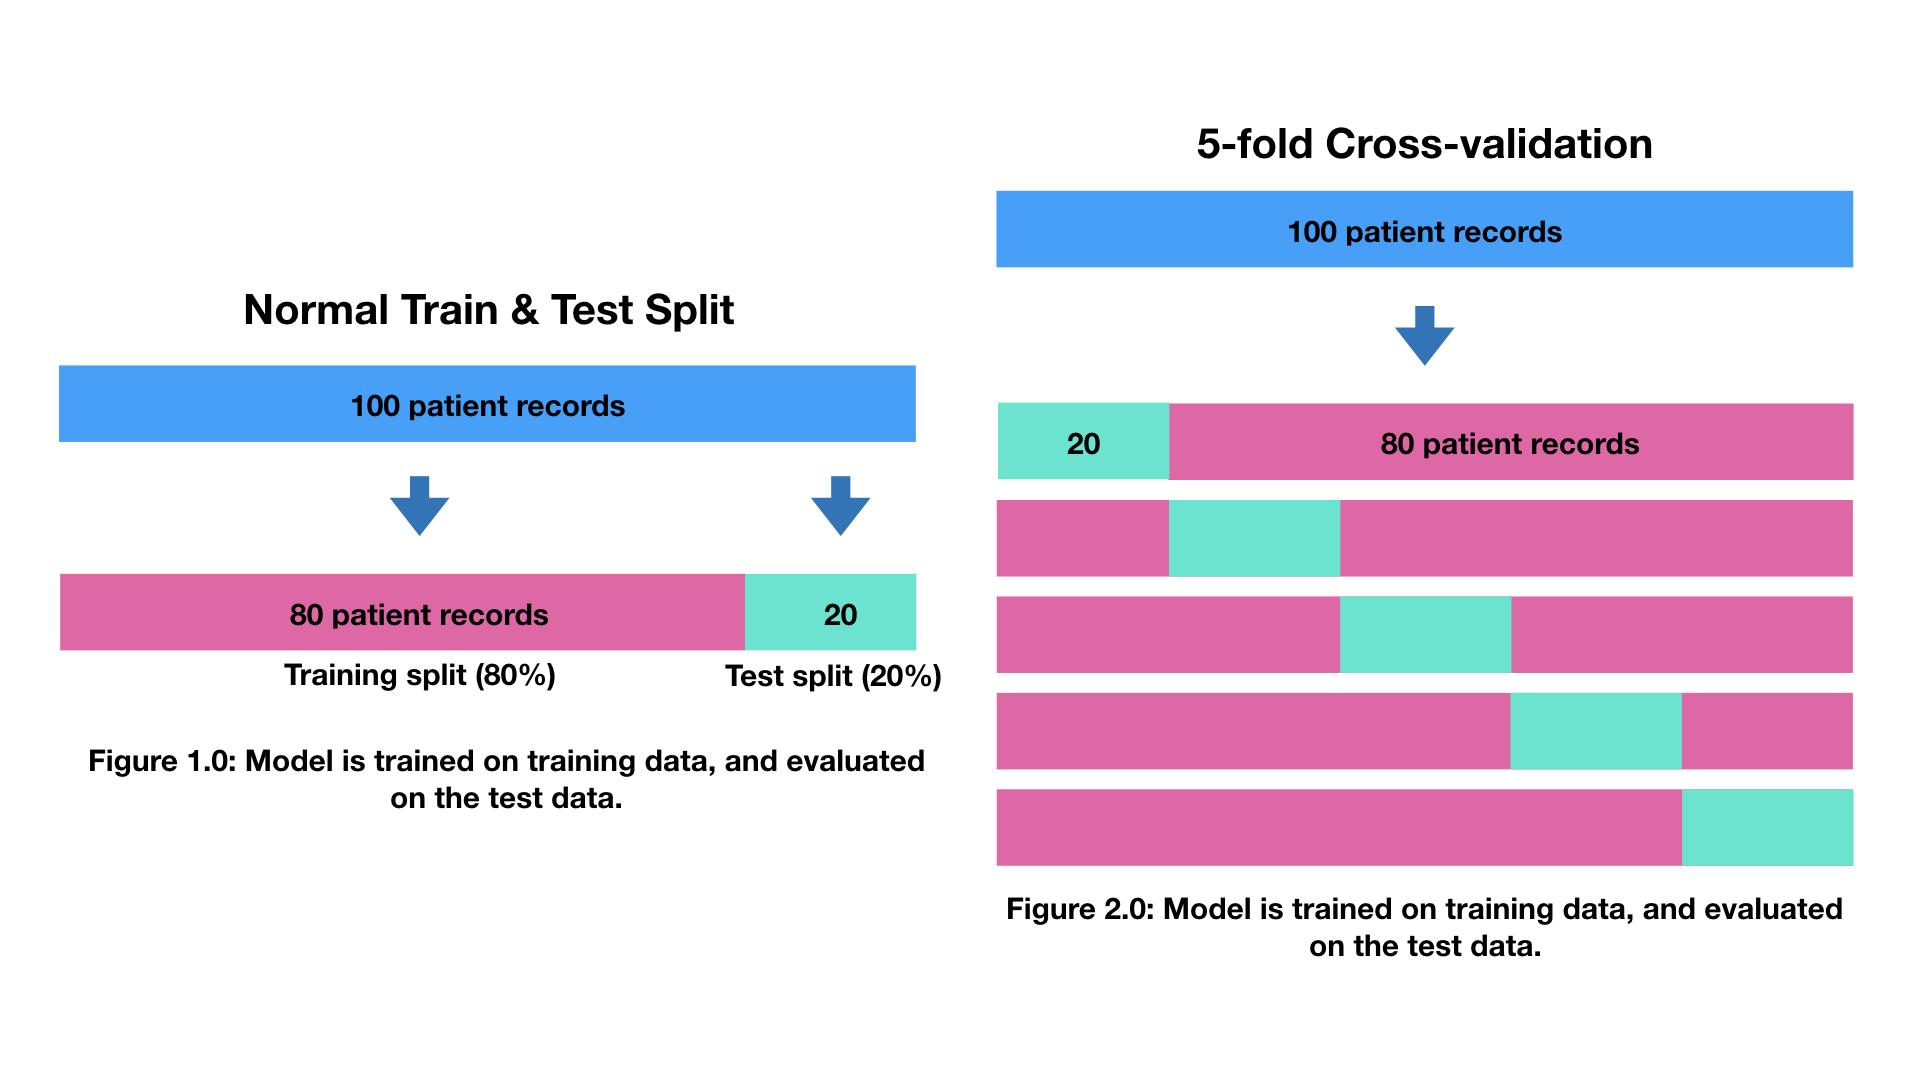
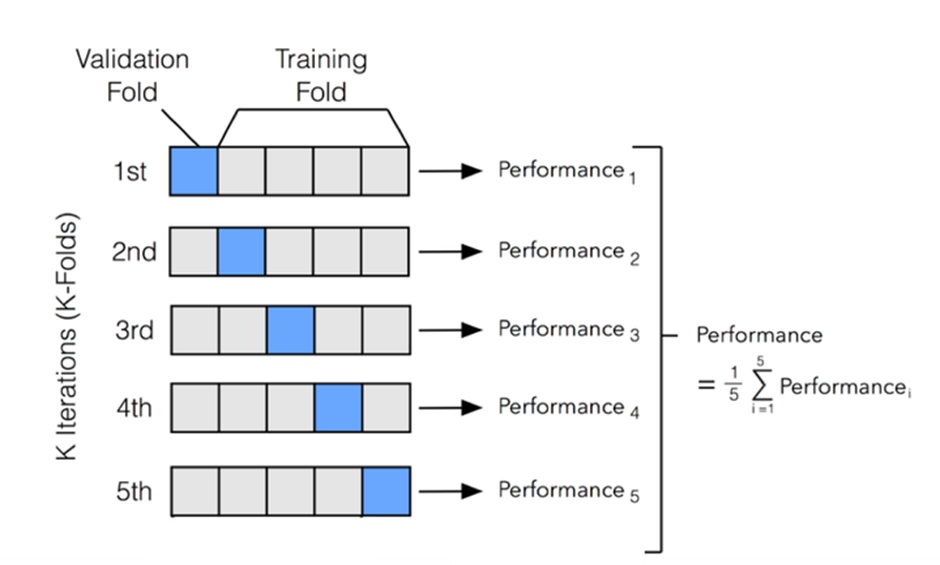

In [86]:
np.random.seed(42)

# Single training and test split score
clf_single_score = clf.score(X_test, y_test)

# Take the mean of 5-fold cross-validation score
clf_cross_val_score = np.mean(cross_val_score(clf, X, y, cv=5))

# Compare the two
clf_single_score, clf_cross_val_score

# CV is better even is lower than Single score

(0.8524590163934426, np.float64(0.8248087431693989))

In [87]:
# Default scoring parameter of classifier = mean accuracy
# clf.score()

# Scoring parameter set to None by default
cross_val_score(clf, X, y, cv=5, scoring=None)

array([0.78688525, 0.86885246, 0.80327869, 0.78333333, 0.76666667])

In [88]:
print("%0.4f accuracy with a standard deviation of %0.4f" % (clf_cross_val_score.mean(), clf_cross_val_score.std()))

0.8248 accuracy with a standard deviation of 0.0000


### 4.2.1 Classification model evaluation metrics

1. Accuracy
2. Area under ROC curve
3. Confusion matrix
4. Classification report

**Accuracy**

In [89]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [90]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_disease.drop('target', axis=1)
y = heart_disease['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

clf = RandomForestClassifier(n_estimators=100)
cross_val_score = cross_val_score(clf, X, y, cv=5)
# estimator : estimator object implementing 'fit'. The object to use to fit the data.
# n_estimators: The number of trees in the forest
# cv: Determines the cross-validation splitting strategy

print(f"Heart Disease Classifier Cross-Validated Accuracy: {np.mean(cross_val_score)*100:.2f}%")

Heart Disease Classifier Cross-Validated Accuracy: 82.15%


**Area under the reciever operating characteristic curve (AUC/ROC)**
* Area under curve (AUC)
* ROC curve

ROC curve are a comparasion of a model's true positive rate (tpr) versus a models false positive rate (fpr)

* True positive = model predicts 1 when truth is 1
* False positive = model predicts 1 when truth is 0
* True negative = model predicts 0 when truth is 0
* False negative = model predicts 0 when truth is 1

In [91]:
# Create X_test ... etc
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [92]:
from sklearn.metrics import roc_curve, auc

# Fit the classifier
clf.fit(X_train, y_train)

# Make predictions with probabilitie
# predict_proba method returns the probability estimates for each possible class of a given input sample, rather than just the final class label
# an array of shape (n_samples, n_classes). Each row corresponds to a sample, and each column corresponds to a class
y_probs = clf.predict_proba(X_test)

y_probs[:10], len(y_probs)
# 0.89 probability of being cero and 0.11 to be 1

(array([[0.89, 0.11],
        [0.05, 0.95],
        [0.1 , 0.9 ],
        [0.79, 0.21],
        [0.09, 0.91],
        [0.02, 0.98],
        [0.76, 0.24],
        [0.19, 0.81],
        [0.62, 0.38],
        [0.99, 0.01]]),
 61)

In [93]:
y_probs_positive = y_probs[:,  1] # we take only ones
y_probs_positive[:10]

array([0.11, 0.95, 0.9 , 0.21, 0.91, 0.98, 0.24, 0.81, 0.38, 0.01])

* Purpose: Evaluates how well a classifier can distinguish between two classes.
* Returns: Three arrays: fpr (False Positive Rates), tpr (True Positive Rates), and thresholds used for the calculation.
* Inputs: Requires true binary labels (y_true) and target scores/probabilities (y_score).

In [94]:
# Calculate fpr, tpr, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs_positive)

## **ROC CURVE**

Is a function that computes the points for a Receiver Operating Characteristic (ROC) curve, which is used to evaluate the performance of binary classification models. 

`Core Functionality: Outputs`

- **FPR (False Positive Rate):** The x-axis coordinates.
- **TPR (True Positive Rate):** The y-axis coordinates (also known as Sensitivity or Recall).
- **Thresholds:** The decreasing decision thresholds used to calculate each FPR and TPR point.

It requires true binary labels and target scores

* AUC  mide la capacidad de clasificación para distinguir entre clases; es la probabilidad que clasifique mejor un ejemplo positivo al azar. más cercano a 1 = distingue entre clases

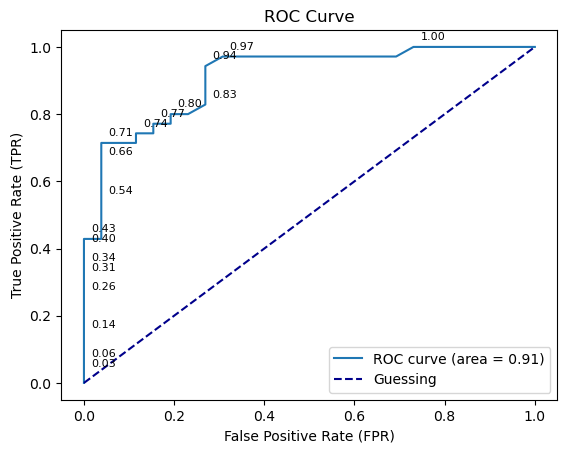

In [95]:
# 1. Compute FPR, TPR, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_probs_positive)

# 2. Calculate Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# 3. Encontrar puntos donde cambia TPR
change_idx = np.where(np.diff(tpr) != 0)[0] + 1

# 4. Anotar SOLO los cambios
for i in change_idx:
    plt.annotate(
        f"{tpr[i]:.2f}",
        (fpr[i], tpr[i]),
        textcoords="offset points",
        xytext=(5,5),
        fontsize=8
    )

# 5. Plotting the result
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='darkblue', label='Guessing')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc="lower right")
plt.title('ROC Curve')
plt.show()

In [96]:
## AUC SCORE
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_test)

1.0

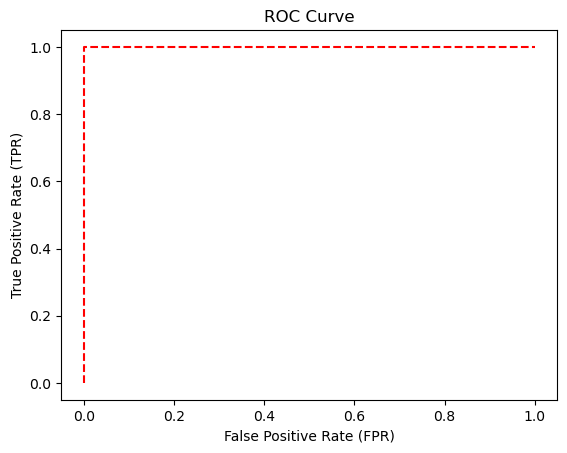

In [97]:
# Plot perfect ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, y_test)
plt.plot(fpr, tpr, linestyle='--', color='red')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve')
plt.show()

Esta gráfica muestra una curva ROC (Receiver Operating Characteristic), que evalúa el rendimiento de un modelo de clasificación binaria.

🔍 ¿Qué estás viendo?
* Eje X (FPR): tasa de falsos positivos → qué tanto el modelo se equivoca clasificando negativos como positivos.
* Eje Y (TPR / sensibilidad): tasa de verdaderos positivos → qué tanto acierta detectando positivos.
* Línea diagonal punteada: un modelo que adivina al azar (AUC = 0.5).
* Curva azul: el rendimiento real del modelo para distintos umbrales.

📊 Interpretación del AUC = 0.87

El AUC (Area Under the Curve) es 0.87, lo cual indica:

* Muy buen desempeño (0.8–0.9 se considera fuerte)
* El modelo tiene un 87% de probabilidad de rankear un positivo real por encima de un negativo.
* Está muy por encima del azar (0.5) pero aún no es perfecto (1.0).

📈 Cómo leer la curva
La curva está bastante cerca de la esquina superior izquierda, lo cual es ideal.
En valores bajos de FPR (~0.1–0.2), ya tienes un TPR alto (~0.7–0.75) → buen equilibrio.
A medida que aumentas el umbral, logras TPR cercanos a 1.0, pero a costa de más falsos positivos.

* 📈Curva ROC y el AUC como nunca te lo habían contado | 🎓Data Concepts

https://www.youtube.com/watch?v=TmhzUdPpVPQ

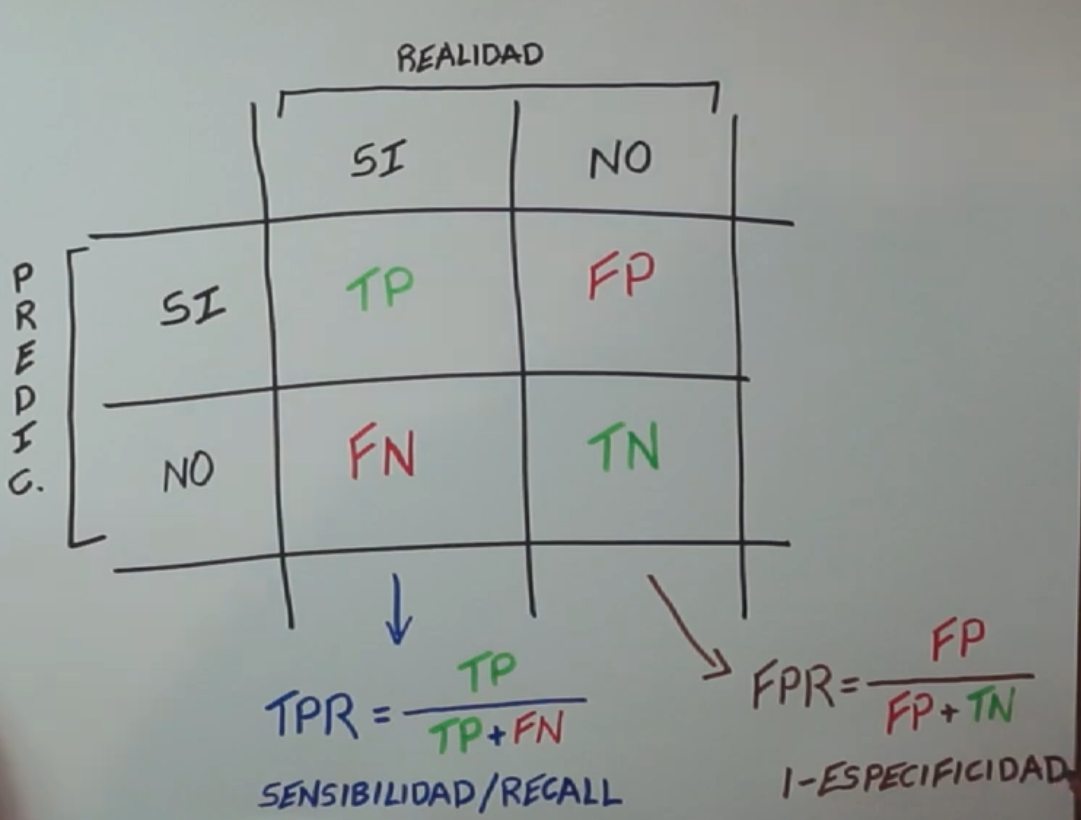

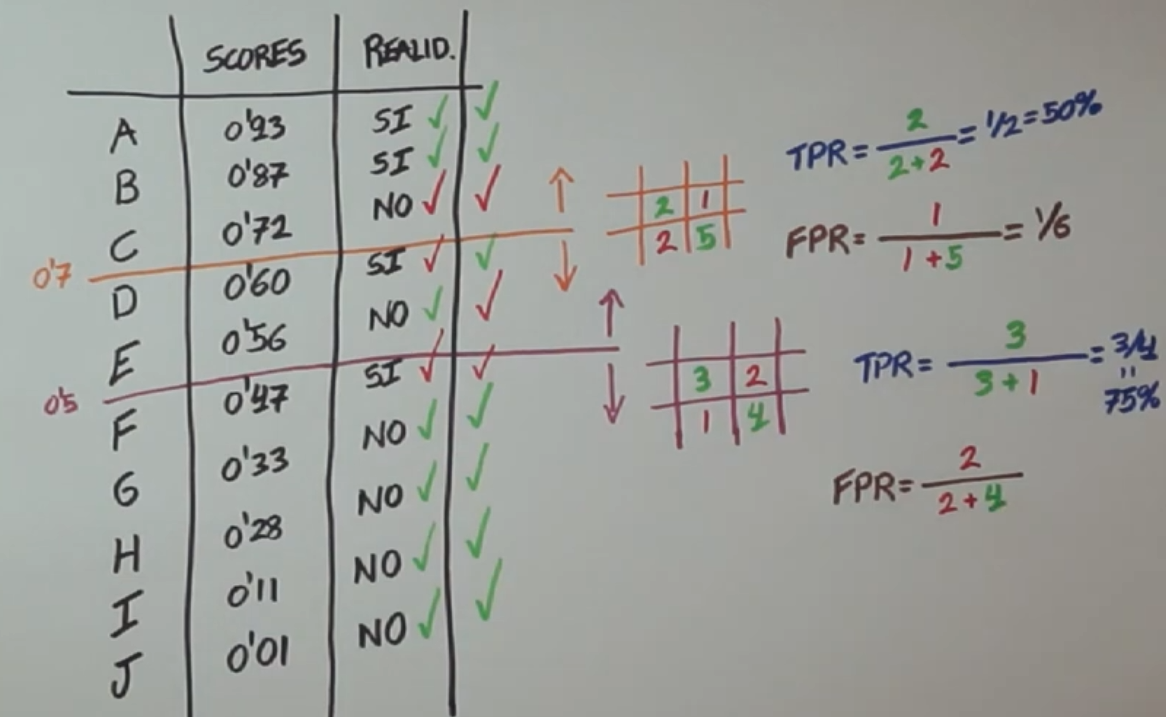

### UDEMY DEF
- ROC curves and AUC metrics are evaluation metrics for binary classification models (a model which predicts one thing or another, such as heart disease or not).

- The ROC curve compares the true positive rate (tpr) versus the false positive rate (fpr) at different classification thresholds.

- The AUC metric tells you how well your model is at choosing between classes (for example, how well it is at deciding whether someone has heart disease or not). A perfect model will get an AUC score of 1.

## **CONFUSION MATRIX**

A confusion matrix is a quick way to compare the labels a model predicts and actual labels it was supposed to predict.
In essence, giving you an idea of where the model is getting confused

In [98]:
X_test.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
213,61,0,0,145,307,0,0,146,1,1.0,1,0,3
140,51,0,2,120,295,0,0,157,0,0.6,2,0,2
15,50,0,2,120,219,0,1,158,0,1.6,1,0,2
202,58,1,0,150,270,0,0,111,1,0.8,2,0,3
88,54,0,2,110,214,0,1,158,0,1.6,1,0,2


In [99]:
from sklearn.metrics import confusion_matrix

y_preds = clf.predict(X_test)

confusion_matrix(y_test, y_preds)

array([[21,  5],
       [ 8, 27]])

In [100]:
# Visualize confusion matrix
pd.crosstab(y_test, y_preds, rownames=['Actual Labels'], colnames=['Predicted Labels'])

Predicted Labels,0,1
Actual Labels,,
0,21,5
1,8,27


In [101]:
len(X_test), 21+8+5+27

(61, 61)

In [102]:
# # Yo lo instale en la terminal, directamente en el ambiente
# # How to install a conda package from JN
# import sys
# !conda install --yes --prefix {sys.prefix} seaborn

<Axes: >

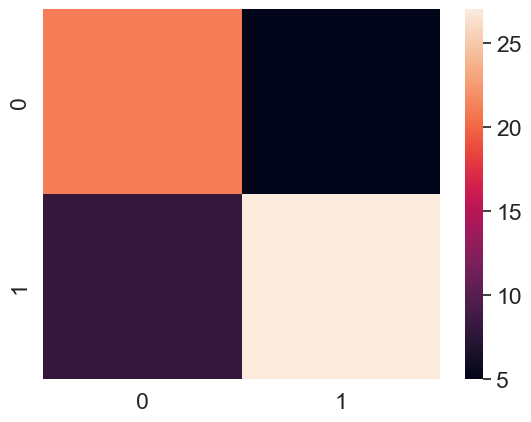

In [103]:
# Make more visual with Seaborn's heatmap()
import seaborn as sns

# Set the font scale
sns.set(font_scale=1.5)

# Create a cm
conf_mat = confusion_matrix(y_test, y_preds)

# Plot it using seaborn
sns.heatmap(conf_mat)

#### Creating a confusion matrix using scikit-learn
To use the new methods of creating a confusion matrix with skicit-learn you will need version 1.0+

In [104]:
import sklearn
sklearn.__version__

'1.7.2'

In [105]:
clf

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [107]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [108]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

### **FROM_ESTIMATOR**

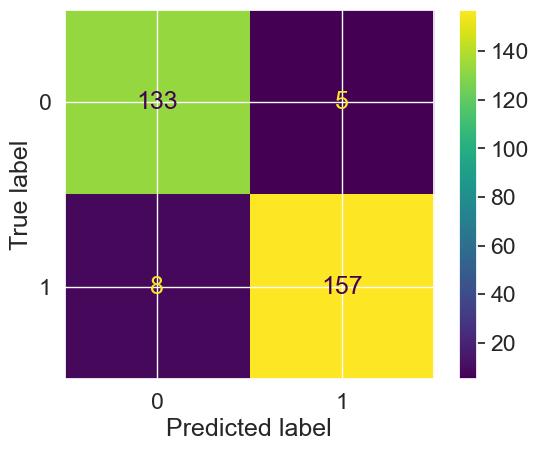

In [111]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(estimator=clf, X=X, y=y); # entire x and y data

### **FROM_PREDICTIONS**

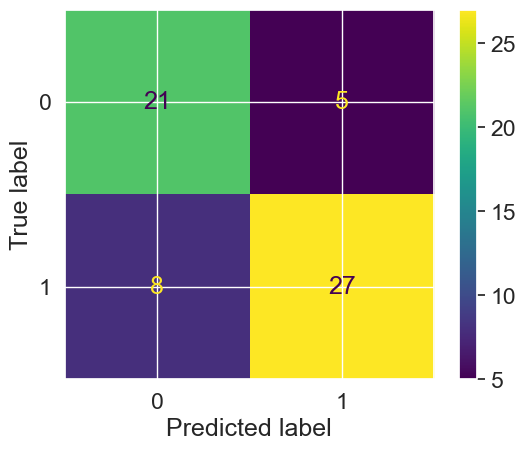

In [112]:
ConfusionMatrixDisplay.from_predictions(y_true=y_test, y_pred=y_preds);

### **CLASSIFICATION REPORT**

In [113]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_preds)) # y_preds = clf.predict(X_test)

              precision    recall  f1-score   support

           0       0.72      0.81      0.76        26
           1       0.84      0.77      0.81        35

    accuracy                           0.79        61
   macro avg       0.78      0.79      0.78        61
weighted avg       0.79      0.79      0.79        61



-  **PRECISION** : Indicates the proportion of positive identifications (model predict class 1) which were actually correct. A model which produces no false positives has precision of 1.0

- **RECAL** : Indicates the proportion of actual positives which were correctly classified. A model which produces no false negatives has a recall of 1.0.